In [59]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
import numpy as np
import random

In [2]:
df = pd.read_csv('homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [3]:
from sklearn import preprocessing

In [4]:
sx = preprocessing.MinMaxScaler()
sy = preprocessing.MinMaxScaler()

X_scaled = sx.fit_transform(df.drop('price', axis='columns'))
X_scaled

array([[0.08827586, 0.25      ],
       [0.62068966, 0.75      ],
       [0.22068966, 0.5       ],
       [0.24862069, 0.5       ],
       [0.13793103, 0.25      ],
       [0.12758621, 0.25      ],
       [0.6662069 , 0.75      ],
       [0.86206897, 0.75      ],
       [0.17586207, 0.5       ],
       [1.        , 1.        ],
       [0.34482759, 0.5       ],
       [0.68448276, 0.75      ],
       [0.06896552, 0.25      ],
       [0.10344828, 0.25      ],
       [0.5       , 0.5       ],
       [0.12931034, 0.25      ],
       [0.13103448, 0.5       ],
       [0.25517241, 0.5       ],
       [0.67931034, 0.5       ],
       [0.        , 0.        ]])

In [5]:
df['price'].shape

(20,)

In [6]:
y_scaled = sy.fit_transform(df['price'].values.reshape(df.shape[0], 1))
y_scaled

array([[0.05237037],
       [0.65185185],
       [0.22222222],
       [0.31851852],
       [0.14074074],
       [0.04444444],
       [0.76296296],
       [0.91111111],
       [0.13333333],
       [1.        ],
       [0.37037037],
       [0.8       ],
       [0.04444444],
       [0.05925926],
       [0.51111111],
       [0.07407407],
       [0.11851852],
       [0.20740741],
       [0.51851852],
       [0.        ]])

In [51]:
number_of_features = X_scaled.shape[1]
w = np.ones(shape = (number_of_features))
w

array([1., 1.])

In [26]:
# batch gradient descent it randomly choose the samples and adjust weight and bias
def batch_gradient_descent(X, y_true, epochs, learning_rate=0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape = (number_of_features))
    b = 0
    total_samples = X.shape[0]
    cost_list = []
    epoch_list = []
    
    for i in range(epochs):
        y_predicted = np.dot(w, X_scaled.T) + b # w1*area + w2 * bedrooms
        w_deriv = -(2/total_samples) * (X.T.dot(y_true - y_predicted))
        b_deriv = -(2/total_samples) * np.sum(y_true - y_predicted)

        w = w - learning_rate * w_deriv
        b = b - learning_rate * b_deriv

        cost = np.mean(np.square(y_true - y_predicted))

        if i%10==0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w, b, cost, cost_list, epoch_list 

In [28]:
w, b, cost, cost_list, epoch_list = batch_gradient_descent(X_scaled, y_scaled.reshape(y_scaled.shape[0],), 500)
w, b, cost

(array([0.70712464, 0.67456527]),
 np.float64(-0.23034857438407427),
 np.float64(0.0068641890429808105))

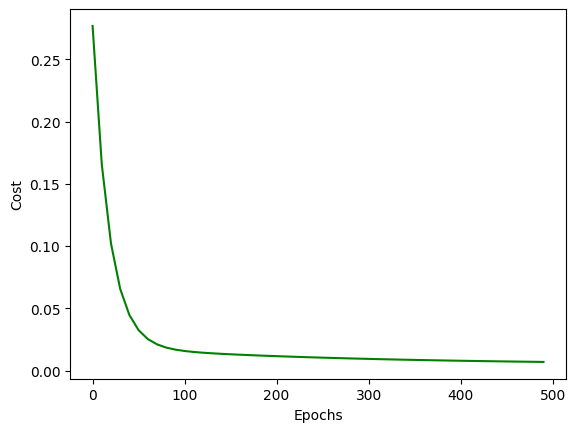

In [33]:
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.plot(epoch_list, cost_list, color='green')
plt.show()

In [40]:
def predict(area, bedrooms, w, b):
    X_scaled = sx.transform([[area, bedrooms]])[0]
    scaled_price = w[0]*X_scaled[0] + w[1]*X_scaled[1] + b

    return sy.inverse_transform([[scaled_price]])

In [45]:
predict(1056, 2, w, b # they are kind of close even is not very much

/home/etiene-niyomugabo123/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([[32.09649526]])

In [44]:
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [66]:
def stochastic_gradient_descent(X, y_true, epochs, learning_rate=0.01):
    number_of_features = X.shape[1]
    w = np.ones(shape = (number_of_features))
    b = 0
    total_samples = X.shape[0]
    cost_list = []
    epoch_list = []

    for i in range (epochs):
        random_index = random.randint(0, total_samples - 1)
        X_sample = X[random_index]
        y_sample = y_true[random_index]
        y_predicted = np.dot(w, X_sample.T) + b

        w_deriv = -(2/total_samples) * (X_sample.T.dot(y_sample - y_predicted))
        b_deriv = -(2/total_samples) * (y_sample - y_predicted)

        w = w - learning_rate * w_deriv
        b = b - learning_rate * b_deriv

        cost = (np.square(y_sample - y_predicted))

        if i % 100 == 0:
            cost_list.append(cost)
            epoch_list.append(i)
    return w, b, cost, cost_list, epoch_list

In [71]:
w_sgd, b_sgd, cost_sgd, cost_list_sgd, epoch_list_sgd = stochastic_gradient_descent(
    X_scaled, y_scaled.reshape(y_scaled.shape[0],), 10000
)

w_sgd, b_sgd, cost_sgd

(array([0.70544355, 0.67461053]),
 np.float64(-0.2319948203695687),
 np.float64(0.05392940155201092))

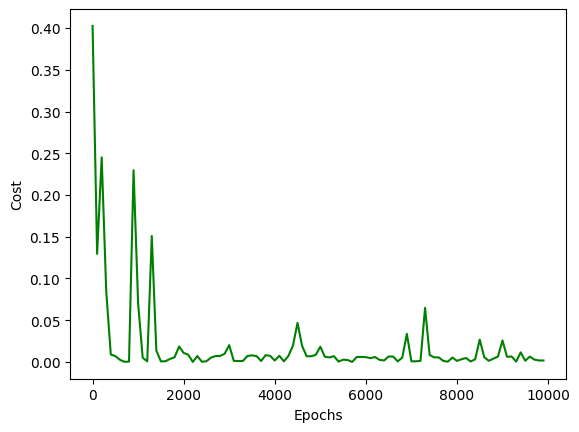

In [72]:
plt.xlabel('Epochs')
plt.ylabel('Cost')
plt.plot(epoch_list_sgd, cost_list_sgd, color='green')
plt.show()